# TAM Testbed — Quickstart

Build Transformational Apparent Motion (TAM) task environments, look at trials, load the shipped reference RNN, and test how it generalizes across TAM stimulus variants.

Setup: see the README (clone with git LFS, then `uv sync`).

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import illusion_rnn as ir

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CKPT = ROOT / "checkpoints"
FIG = ROOT / "figures"
print("illusion_rnn", ir.__version__)

illusion_rnn 1.0.0


## 1. Task environments

A TAM trial: fixation → an *init* frame (two end shapes) → a second frame where a bar connects them, with an extra element that disambiguates the motion direction → a blank decision period. Ground truth is `fixation` (0) until the second frame appears, then the direction (left=1, middle=2, right=3).

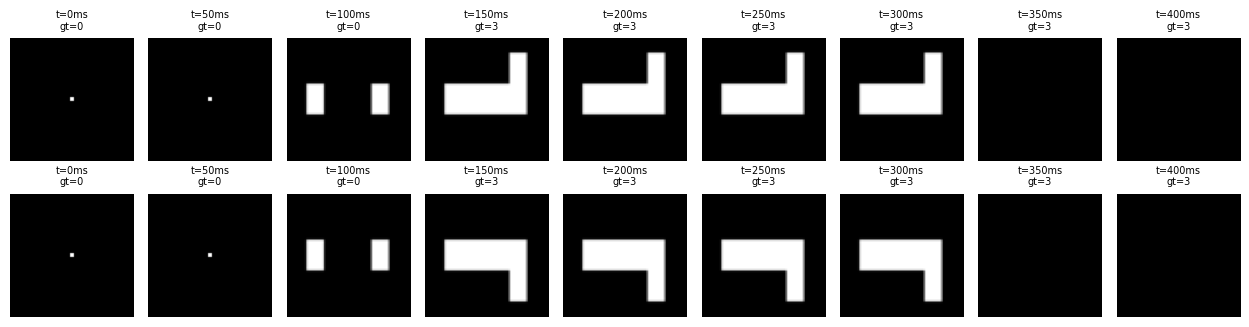

In [2]:
env = ir.make_env("tam", box_shape="square", variant="standard",
                  stim_ori="horizontal", img_size=64)
env.seed(0)
fig = ir.plot_trials(env, n_trials=2, save_path=FIG / "sample_trials.png")

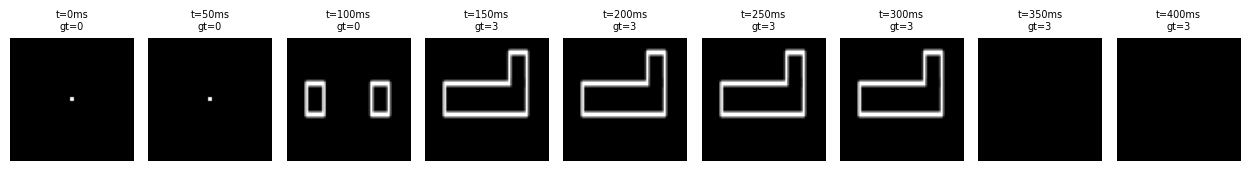

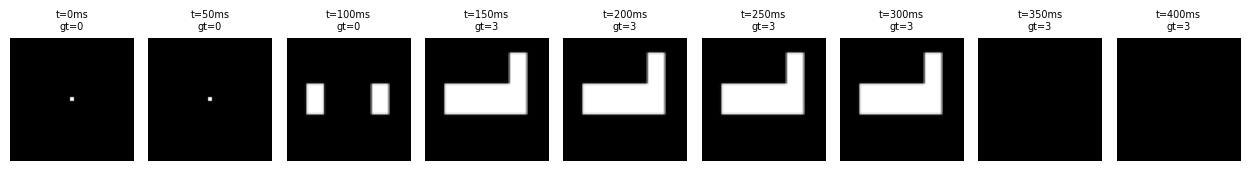

In [3]:
for variant in ("outline", "basic"):
    env = ir.make_env("tam", box_shape="square", variant=variant,
                      stim_ori="horizontal", img_size=64)
    env.seed(0)
    ir.plot_trials(env, n_trials=1)

The motion control task shows *real* frame-by-frame motion (`continuous` or `tracking`), used to train networks on unambiguous motion before testing them on TAM.

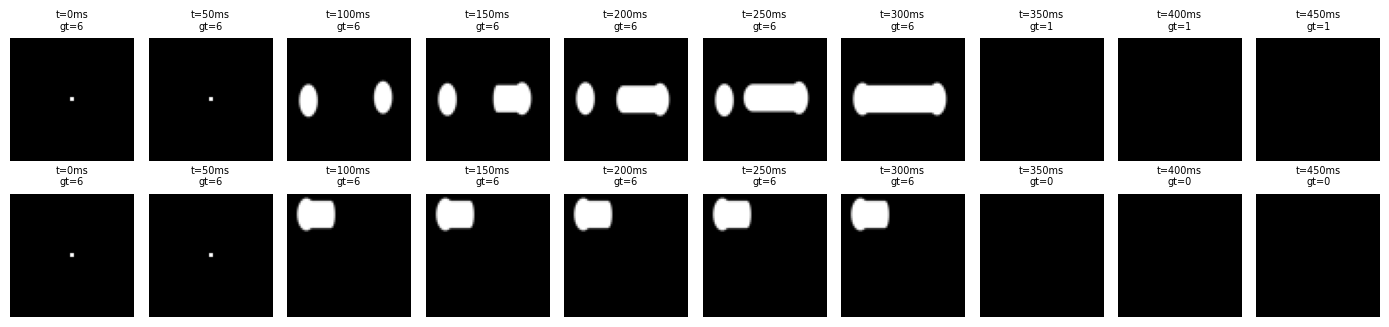

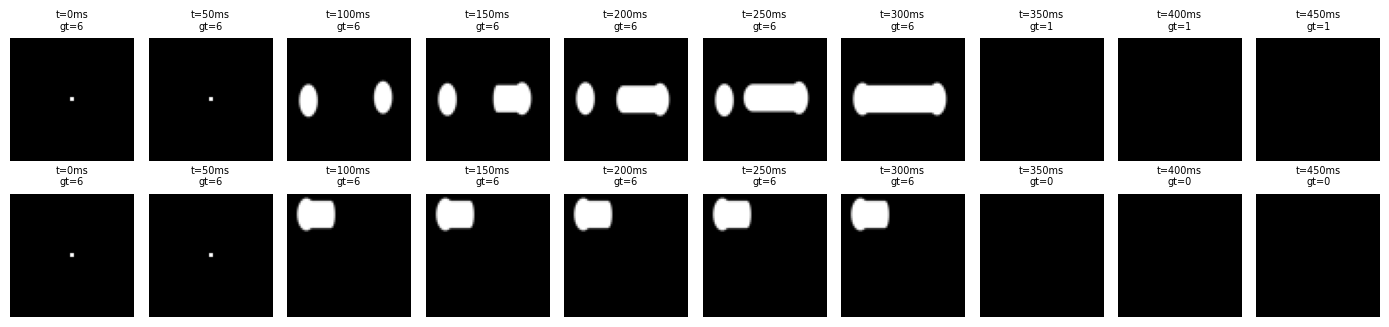

In [4]:
env = ir.make_env("motion", box_shape="circle", motion_type="continuous",
                  stim_ori="horizontal", img_size=64)
env.seed(0)
ir.plot_trials(env, n_trials=2)

## 2. Load the shipped reference RNN

A continuous-time RNN (4096 → 2048 → 6) trained on raw 64×64 pixels of the horizontal *standard* TAM set (all three shapes).

In [5]:
flagship = CKPT / "rnn-pixel_h2048_tam-horiz.pt"
assert flagship.stat().st_size > 1024, (
    "Checkpoint is an LFS pointer; run: git lfs install --local && git lfs checkout"
)
model = ir.load_rnn(flagship)
sum(p.numel() for p in model.parameters())

12599302

## 3. Generalization across TAM variants

Evaluate on the training condition (*standard*) and on the unseen *outline* and *basic* variants — 100 trials per shape per variant.

In [6]:
variants = ("standard", "outline", "basic")
results = {}
for variant in variants:
    accs = []
    for shape in ir.SHAPES:
        env = ir.make_env("tam", box_shape=shape, variant=variant,
                          stim_ori="horizontal", img_size=64)
        env.seed(0)
        accs.append(ir.evaluate(model, env, n_trials=100, device="cpu").accuracy)
    results[variant] = accs
    print(f"{variant:9s}", {s: round(a, 3) for s, a in zip(ir.SHAPES, accs)})

standard  {'square': 1.0, 'circle': 1.0, 'triangle': 0.9}


outline   {'square': 0.3, 'circle': 0.0, 'triangle': 0.0}


basic     {'square': 1.0, 'circle': 1.0, 'triangle': 0.9}


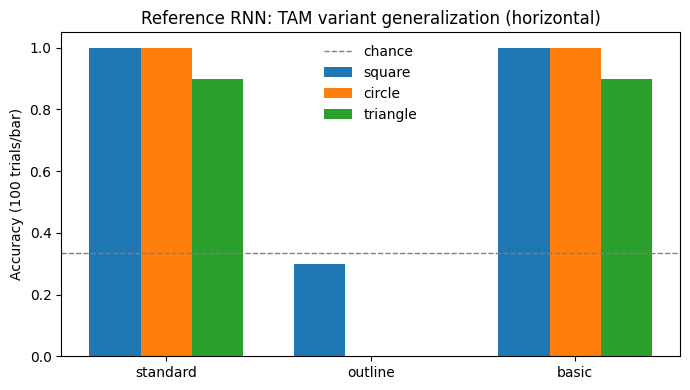

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(variants))
width = 0.25
for i, shape in enumerate(ir.SHAPES):
    ax.bar(x + (i - 1) * width, [results[v][i] for v in variants],
           width, label=shape)
ax.axhline(1 / 3, color="gray", ls="--", lw=1, label="chance")
ax.set_xticks(x)
ax.set_xticklabels(variants)
ax.set_ylabel("Accuracy (100 trials/bar)")
ax.set_title("Reference RNN: TAM variant generalization (horizontal)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG / "generalization.png", dpi=150, bbox_inches="tight")

## 4. A glance at the hidden dynamics

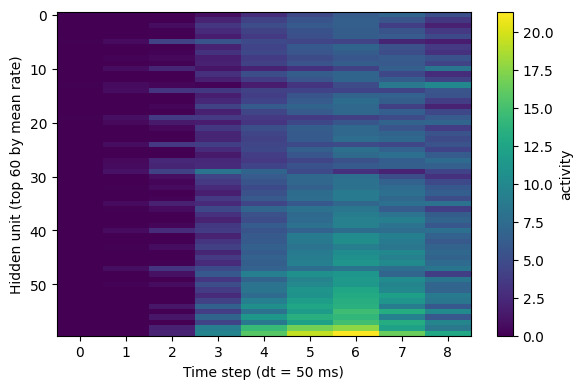

In [8]:
env = ir.make_env("tam", box_shape="square", variant="standard",
                  stim_ori="horizontal", img_size=64)
env.seed(3)
res = ir.evaluate(model, env, n_trials=1, device="cpu")
act = res.activity[0]  # (T, hidden)
order = np.argsort(act.mean(axis=0))[-60:]
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(act[:, order].T, aspect="auto", cmap="viridis")
ax.set_xlabel(f"Time step (dt = {env.dt} ms)")
ax.set_ylabel("Hidden unit (top 60 by mean rate)")
fig.colorbar(im, label="activity")
fig.tight_layout()

## 5. Plug in your own model

Anything with the interface `model(x: (T, B, F) tensor) -> (out (T, B, 6), activity (T, B, H))` drops into `ir.evaluate` / `ir.train`. To test a frame encoder instead of raw pixels, pass `encoder=ir.cnn_encoder(your_cnn)` — see `checkpoints/MANIFEST.md` for the shipped CNN-features models, and the README for custom stimuli.